# **LAB SLOT 12 - BIGRAM TEXT GENERATION & RANKING**
**Sinh viên:** Nguyễn Văn Anh Duy  
**MSSV:** SE181823  
**Lớp:** AI1803

---
**Yêu cầu:** Xây dựng mô hình bigram để sinh câu tự động từ Aristo mini-corpus, tìm và xếp hạng 10 cụm từ dài nhất được tạo ra.

## 1. Import Libraries

In [45]:
import os
import re
import time
from collections import defaultdict, Counter
from pathlib import Path
import zipfile
import warnings
from tqdm.auto import tqdm
warnings.filterwarnings('ignore')

print("Libraries imported successfully")

Libraries imported successfully


In [46]:
# Cài đặt thư viện progress bar
!pip install -q tqdm
print("✓ tqdm installed for progress tracking")

✓ tqdm installed for progress tracking


## 2. Load Dataset

[Aristo Mini Corpus](https://www.kaggle.com/datasets/allenai/aristo-mini-corpus)

In [47]:
# Cài đặt Kaggle CLI
!pip install -q kaggle
print("✓ Kaggle CLI installed")

✓ Kaggle CLI installed


In [57]:
# Setup Kaggle credentials
import json
from pathlib import Path

KAGGLE_USERNAME = "vananhduy"  # Thay username của bạn
KAGGLE_KEY = "KGAT_54084979027bcbc9ac85fc85a1c113fe"

kaggle_dir = Path.home() / '.kaggle'
kaggle_dir.mkdir(exist_ok=True)

with open(kaggle_dir / 'kaggle.json', 'w') as f:
    json.dump({"username": KAGGLE_USERNAME, "key": KAGGLE_KEY}, f)

import os
os.chmod(kaggle_dir / 'kaggle.json', 0o600)

print(f"✓ Configured: {KAGGLE_USERNAME}")

✓ Configured: vananhduy


In [58]:
# Tạo thư mục data
DATA_DIR = Path("data")
DATA_DIR.mkdir(exist_ok=True)

dataset_path = DATA_DIR / "aristo-mini-corpus.zip"

# Download dataset nếu chưa có
if not dataset_path.exists():
    print("Downloading dataset from Kaggle...")
    !kaggle datasets download -d allenai/aristo-mini-corpus -p data/ --force
    if dataset_path.exists():
        print(f"✓ Downloaded: {dataset_path.stat().st_size / 1024 / 1024:.1f} MB")
else:
    print(f"✓ Dataset exists: {dataset_path.stat().st_size / 1024 / 1024:.1f} MB")

# Giải nén
if dataset_path.exists():
    print("Extracting...")
    with zipfile.ZipFile(dataset_path, 'r') as zip_ref:
        zip_ref.extractall(DATA_DIR)
    print(f"✓ Extracted to: {DATA_DIR.absolute()}")

# Load corpus
txt_files = list(DATA_DIR.glob("**/*.txt"))
if txt_files:
    CORPUS_FILE = txt_files[0]
    corpus_text = CORPUS_FILE.read_text(encoding='utf-8')
    print(f"\n✓ Loaded: {CORPUS_FILE.name}")
    print(f"  Characters: {len(corpus_text):,}")
    print(f"  Lines: {len(corpus_text.splitlines()):,}")
    print(f"\nPreview:\n{corpus_text[:200]}...")
else:
    print("✗ No .txt files found")
    corpus_text = ""

Dataset URL: https://www.kaggle.com/datasets/allenai/aristo-mini-corpus
License(s): CC-BY-SA-4.0
100%|██████████████████████████████████████| 34.9M/34.9M [00:02<00:00, 12.8MB/s]

✓ Downloaded: 34.9 MB
Extracting...
✓ Extracted to: /Users/vananhduy/Documents/Repository_Git_Hub/SP26/DAT301m/labs/LAB_SLOT_12/data

✓ Loaded: Aristo-Mini-Corpus-Dec2016.txt
  Characters: 103,214,529
  Lines: 1,197,382

Preview:
Plants can do both.
Energy often moves.
The water does not change, it is still water.
Energy is energy.
Energy - is moving energy.
And the plant is food to the animal.
Animals get their food from plan...


## Yêu cầu 1: Tiền xử lý dữ liệu (Pre-processing)

**Mục tiêu:**

1. Chuyển toàn bộ văn bản về chữ thường (lowercase)
2. Tách các câu thành từ đơn (word tokens)
3. Lọc bỏ noise: số, Wikipedia/HTML tokens, từ quá ngắn/dài
4. GIỮ stop words (a, the, is...) để câu sinh ra có nghĩa tự nhiên

In [ ]:
def preprocess_corpus(text, min_word_length=2, min_word_freq=2, max_word_length=20):
    """
    TIỀN XỬ LÝ DỮ LIỆU (Yêu cầu 1)
    
    Xử lý:
    1. Chuyển về lowercase (chữ thường)
    2. Tách câu và tokenize thành từ đơn
    3. Lọc bỏ noise: số, HTML tokens, từ quá ngắn/dài
    4. GIỮ stop words để câu có nghĩa
    """
    # Danh sách noise tokens cần loại bỏ
    noise_tokens = {
        'http', 'https', 'www', 'html', 'htm', 'wiki', 'wikipedia',
        'div', 'span', 'href', 'src', 'img', 'cite', 'ref', 'url',
    }
    
    print("Preprocessing corpus...")
    
    # Bước 1: Chuyển về chữ thường (lowercase)
    text = text.lower()
    
    # Bước 2: Tách câu
    sentences = re.split(r'[.!?\n]+', text)
    sentences = [s.strip() for s in sentences if s.strip()]
    
    tokenized_sentences = []
    word_freq = Counter()
    filtered_count = 0
    
        # Bước 3: Loại bỏ ký tự đặc biệt và tokenize thành từ
        # Loại bỏ ký tự đặc biệt
        clean_sent = re.sub(r'[^\w\s]', '', sent)
        tokens = clean_sent.split()
        
        filtered_words = []
            # Lọc bỏ: noise, số, từ quá ngắn/dài
            # Chỉ loại bỏ: noise tokens, số, từ quá ngắn/dài, mixed alphanumeric
            if (len(word) < min_word_length or 
                len(word) > max_word_length or
                word.isdigit() or
                any(char.isdigit() for char in word) or
                word in noise_tokens or
                any(token in word for token in ['http', 'www'])):
                filtered_count += 1
            
            # GIỮ lại stop words (a, the, is...) để câu có nghĩa    
            filtered_words.append(word)
            word_freq[word] += 1
        
        if len(filtered_words) >= 2:
            tokenized_sentences.append(filtered_words)
    
    # Lọc từ hiếm
    valid_words = {word for word, freq in word_freq.items() if freq >= min_word_freq}
    filtered_sentences = [
        [w for w in sent if w in valid_words] 
        for sent in tokenized_sentences
    ]
    filtered_sentences = [s for s in filtered_sentences if len(s) >= 2]
    
    # Loại bỏ duplicate
    dedup_sentences = []
    for sentence in filtered_sentences:
        deduped = [word for i, word in enumerate(sentence) 
                   if i == 0 or word != sentence[i-1]]
        if len(deduped) >= 2:
            dedup_sentences.append(deduped)
    
    # Loại bỏ câu trùng lặp
    seen = set()
    unique_sentences = []
    for sentence in dedup_sentences:
        key = ' '.join(sentence)
        if key not in seen:
            seen.add(key)
            unique_sentences.append(sentence)
    
    # Summary
    total_words = sum(len(s) for s in unique_sentences)
    unique_words = len(set(w for s in unique_sentences for w in s))
    
    print(f"\n{'='*70}")
    print("PREPROCESSING SUMMARY")
    print(f"{'='*70}")
    print(f"Sentences: {len(sentences):,} → {len(unique_sentences):,}")
    print(f"Unique words: {unique_words:,} | Avg length: {total_words/len(unique_sentences):.1f} words")
    print(f"Filtered tokens: {filtered_count:,} (noise/numbers/length)")
    print(f"{'='*70}\n")
    
    return unique_sentences
# Thực thi tiền xử lý
# Tiền xử lý - GIỮ stop words để câu có nghĩa
tokenized_corpus = preprocess_corpus(
    min_word_length=2,
    min_word_freq=2,
    max_word_length=20
)

))

Preprocessing corpus...


Processing:   0%|          | 0/1573484 [00:00<?, ?it/s]


PREPROCESSING SUMMARY
Sentences: 1,573,484 → 939,391
Unique words: 165,875 | Avg length: 12.2 words
Filtered tokens: 1,476,536 (noise/numbers/length)



## Yêu cầu 2: Xây dựng đồ thị liên kết từ (Word Graph/Bigram Model)

- Kết quả: Đồ thị có hướng, mỗi từ trỏ đến các từ có thể đi tiếp theo

**Mục tiêu:** Duyệt qua tập dữ liệu để tìm ra quy luật từ tiếp theo- Với mỗi cặp từ liên tiếp (bigram), lưu lại mối quan hệ word1 → word2

**Nguyên lý:** 

In [ ]:
def build_word_graph(tokenized_sentences):
    """
    XÂY DỰNG WORD GRAPH (Yêu cầu 2)
    
    Nguyên lý: Duyệt qua dataset, với mỗi cặp từ liên tiếp (w1, w2),
    lưu lại mối quan hệ w1 → w2 vào đồ thị
    
    Returns:
        dict: {word: [list_of_next_words]}
    """
    # Dùng set để tự động loại bỏ duplicate bigrams
    word_graph = defaultdict(set)
    
    # Duyệt qua từng câu và tìm quy luật từ tiếp theo
    for sentence in tqdm(tokenized_sentences, desc="Building bigram graph"):
        for i in range(len(sentence) - 1):
            current_word = sentence[i]
            next_word = sentence[i + 1]
            # Lưu mối quan hệ: current_word có thể theo sau bởi next_word

            word_graph[current_word].add(next_word)word_graph = build_word_graph(tokenized_corpus)

    

    # Convert set về list để dễ sử dụng    return word_graph

    word_graph = {word: list(neighbors) for word, neighbors in word_graph.items()}    

        print(f"\n✓ Bigram Graph: {nodes:,} nodes (từ), {edges:,} edges (mối liên kết)\n")

    # In thông tin đồ thị    edges = sum(len(neighbors) for neighbors in word_graph.values())
    nodes = len(word_graph)

Building bigram graph:   0%|          | 0/939391 [00:00<?, ?it/s]


✓ Bigram Graph: 157,813 nodes, 2,581,351 edges



In [ ]:
# Phân tích cơ bản về đồ thị
print(f"\nPhân tích đồ thị:")
out_degrees = {word: len(neighbors) for word, neighbors in word_graph.items()}
print(f"Top 5 từ có nhiều kết nối nhất:")
for word, degree in sorted(out_degrees.items(), key=lambda x: x[1], reverse=True)[:5]:
    print(f"  '{word}' → {degree} từ tiếp theo")
print()


GRAPH ANALYSIS
Nodes: 157,813 | Edges: 2,581,351
Avg degree: 16.36

Top 5 most connected words:
  'the' → 40924 connections
  'and' → 33405 connections
  'of' → 32168 connections
  'lrb' → 20845 connections
  'in' → 20475 connections



## Visualization: Hiển thị đồ thị Bigram

(Tùy chọn - không bắt buộc cho báo cáo)


Building visualization...


Creating graph:   0%|          | 0/50 [00:00<?, ?it/s]

✓ Subgraph: 50 nodes, 2233 edges
Rendering graph...


<Figure size 2400x2000 with 0 Axes>

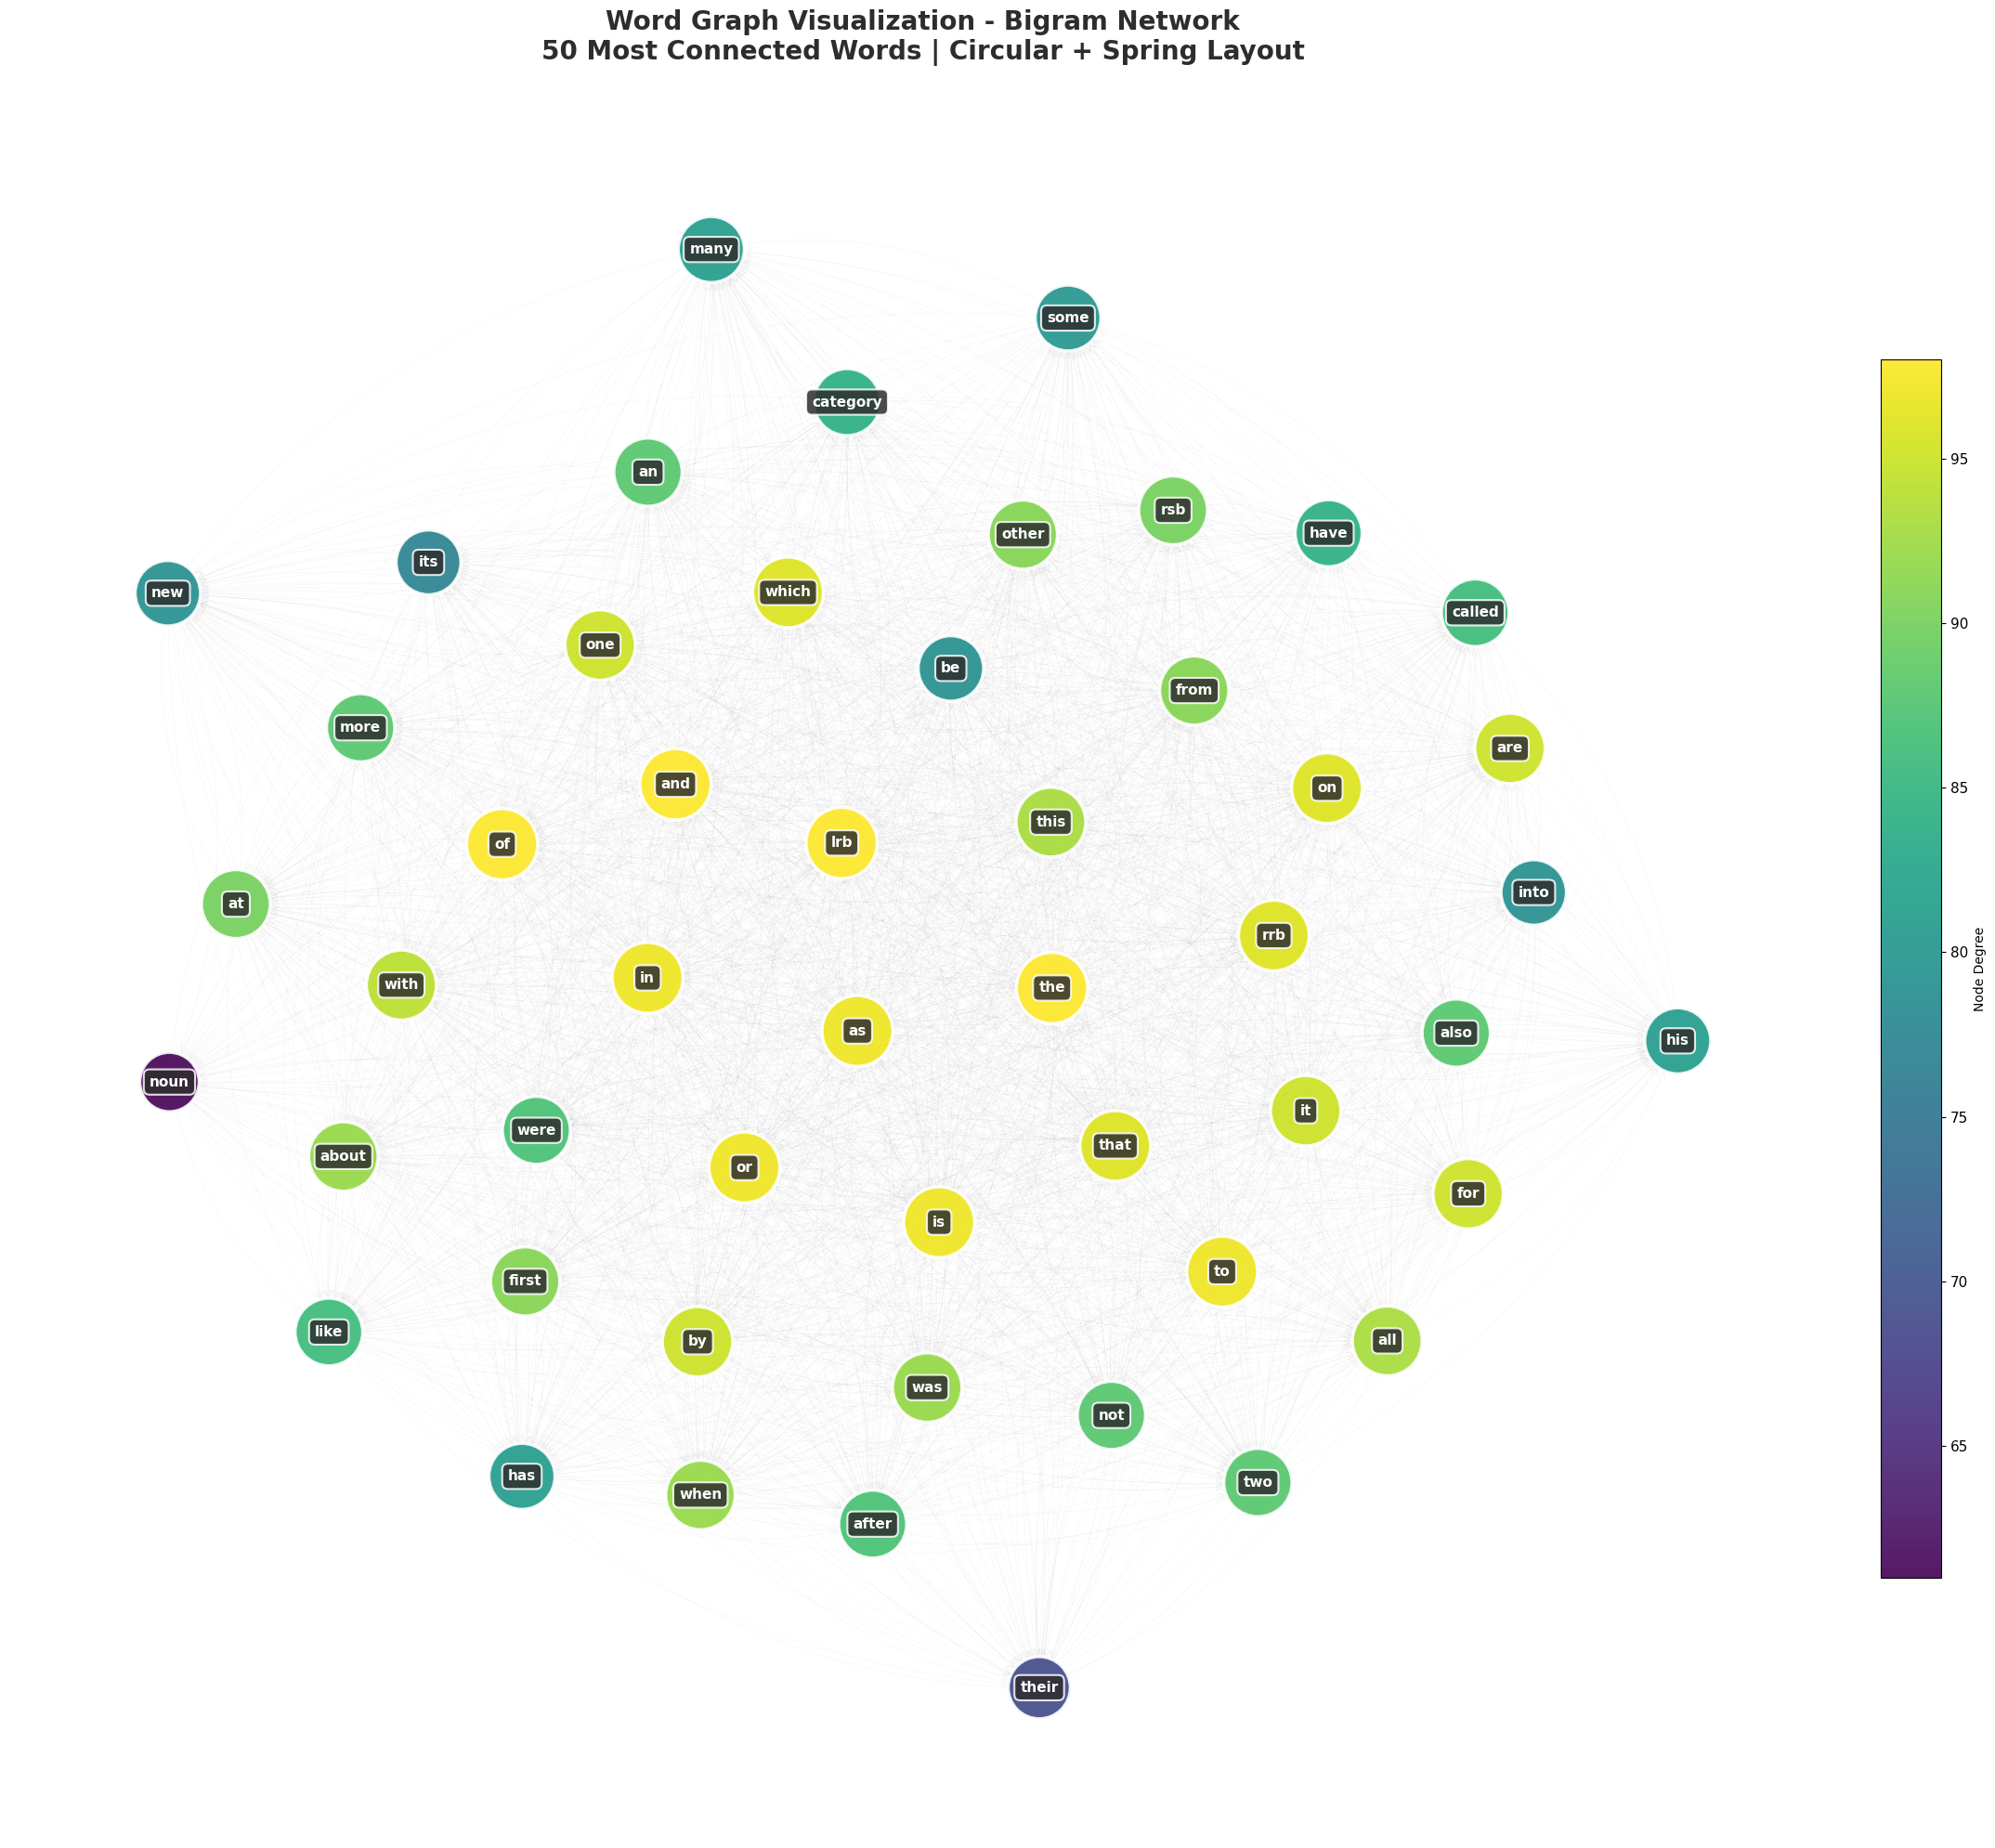


GRAPH STATISTICS

✓ Visualized: 50 nodes, 2233 edges



In [ ]:
import networkx as nx
import matplotlib.pyplot as plt

def visualize_word_graph_subset(word_graph, max_nodes=50, min_connections=3):
    """Hiển thị đồ thị bigram với các từ có nhiều kết nối nhất"""
    
    # Lọc các từ có nhiều kết nối
    node_degrees = {word: len(neighbors) for word, neighbors in word_graph.items()}
    top_nodes = [word for word, degree in sorted(node_degrees.items(), 
                                                  key=lambda x: x[1], 
                                                  reverse=True)[:max_nodes] 
                 if degree >= min_connections]
    
    # Tạo đồ thị NetworkX
    G = nx.DiGraph()
    for word in tqdm(top_nodes, desc="Creating graph"):
        for next_word in word_graph[word]:
            if next_word in top_nodes:
                if G.has_edge(word, next_word):
                    G[word][next_word]['weight'] += 1
                else:
                    G.add_edge(word, next_word, weight=1)
    
    print(f"✓ Subgraph: {G.number_of_nodes()} nodes, {G.number_of_edges()} edges")
    
    # Vẽ đồ thị
    plt.figure(figsize=(24, 20))
    
    node_degrees_in_G = dict(G.degree())
    pos = nx.spring_layout(G, k=8, iterations=200, scale=3.5, seed=42)
    
    node_sizes = [600 + node_degrees_in_G[node] * 25 for node in G.nodes()]
    node_colors = [node_degrees_in_G[node] for node in G.nodes()]
    
    edges = G.edges()
    weights = [G[u][v]['weight'] for u, v in edges]
    
    # Vẽ edges
    nx.draw_networkx_edges(
        G, pos, width=[w*0.2 for w in weights], alpha=0.15, 
        edge_color='#888888', arrows=True, arrowsize=15, 
        arrowstyle='->', connectionstyle='arc3,rad=0.2',
        node_size=node_sizes
    )
    
    # Vẽ nodes
    nodes = nx.draw_networkx_nodes(
        G, pos, node_size=node_sizes, node_color=node_colors,
        cmap=plt.cm.viridis, alpha=0.9,
        vmin=min(node_colors), vmax=max(node_colors),
        edgecolors='white', linewidths=2.5
    )
    
    # Vẽ labels
    for node, (x, y) in pos.items():
        plt.text(
            x, y, node, fontsize=11, fontweight='bold', color='white',
            ha='center', va='center',
            bbox=dict(boxstyle='round,pad=0.4', facecolor='#2d2d2d',
                     edgecolor='white', alpha=0.85, linewidth=1.5),
            zorder=10
        )
    
    # Colorbar và title
    cbar = plt.colorbar(nodes, label='Node Degree', shrink=0.7, pad=0.02)
    cbar.ax.tick_params(labelsize=11)
    
    plt.title(
        f"Word Graph Visualization - Bigram Network\n" +
        f"{len(top_nodes)} Most Connected Words",
        fontsize=20, fontweight='bold', pad=30, color='#2d2d2d'
    )
    
    plt.axis('off')
    plt.tight_layout()
    plt.show()
    
    print(f"✓ Visualized: {G.number_of_nodes()} nodes, {G.number_of_edges()} edges\n")
    return G

# Visualize word graph
G = visualize_word_graph_subset(word_graph, max_nodes=50, min_connections=3)

In [ ]:
# Cài đặt thư viện visualization
%pip install -q networkx matplotlib


[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: pip3.10 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


## Yêu cầu 3: Thuật toán sinh câu (Text Generation)

- Dừng khi không tìm được từ tiếp theo thỏa mãn điều kiện

**Mục tiêu:** Bắt đầu từ một từ bất kỳ, liên tục nối thêm từ tiếp theo dựa trên bigram graph- KHÔNG được phép đi qua từ đã xuất hiện trong chuỗi hiện tại

- Sử dụng `visited` set để lưu các từ đã xuất hiện
**Cơ chế chống lặp vô hạn (Infinite Loop Prevention):**

In [ ]:
def generate_phrase_from_word(start_word, word_graph):
    """
    SINH CỤM TỪ VỚI CƠ CHẾ CHỐNG LẶP VÔ HẠN (Yêu cầu 3)
    
    Thuật toán:
    1. Bắt đầu từ start_word
    2. Tìm từ tiếp theo từ bigram graph
    3. Kiểm tra: từ tiếp theo CHƯA xuất hiện trong visited set
    4. Thêm từ mới vào cụm từ và đánh dấu visited
    5. Dừng khi không còn từ tiếp theo thỏa mãn
    """
    if start_word not in word_graph:
        return start_word
    
    phrase = [start_word]
    visited = {start_word}  # Set lưu các từ đã đi qua (CHỐNG LẶP VÔ HẠN)
    current_word = start_word
    
    while True:
        # Lấy danh sách từ tiếp theo CHƯA được visit
        unvisited_next = [w for w in word_graph.get(current_word, []) 
                         if w not in visited]
        
        # Dừng nếu không còn từ tiếp theo
        if not unvisited_next:
            break
            
        # Chọn từ tiếp theo (lấy từ đầu tiên)
        next_word = unvisited_next[0]
        phrase.append(next_word)
        visited.add(next_word)  # Đánh dấu đã visit
        current_word = next_word

    generated_phrases = generate_all_phrases(word_graph)

    return ' '.join(phrase)

    return all_phrases

def generate_all_phrases(word_graph):    

    """Thu thập tất cả cụm từ từ mọi từ khởi đầu"""    print(f"\n✓ Generated {len(all_phrases):,} phrases (max: {max(lengths)} words)\n")

    all_phrases = []    lengths = [len(p.split()) for p in all_phrases]

    for w in tqdm(word_graph.keys(), desc="Generating phrases"):    
        all_phrases.append(generate_phrase_from_word(w, word_graph))

Generating phrases:   0%|          | 0/157813 [00:00<?, ?it/s]


✓ Generated 157,813 phrases (max: 155 words)



## Yêu cầu 4: Xếp hạng và xuất kết quả (Ranking & Output)

5. In ra Top 10 cụm từ dài nhất

**Mục tiêu:**4. Sắp xếp giảm dần theo độ dài

1. Thu thập tất cả câu/cụm từ sinh ra3. Đếm số từ trong mỗi câu
2. Loại bỏ câu trùng lặp

In [ ]:
def rank_and_display_top_phrases(phrases, top_n=10):
    """
    XẾP HẠNG VÀ XUẤT KẾT QUẢ (Yêu cầu 4)
    
    Các bước:
    1. Loại bỏ câu trùng lặp (set)
    2. Đếm số từ trong mỗi câu
    3. Sắp xếp giảm dần theo độ dài
    4. In ra Top N dài nhất
    """
    # Bước 1: Loại bỏ câu trùng lặp
    unique_phrases = list(set(phrases))
    
    # Bước 2: Đếm số từ trong mỗi câu
    phrases_with_length = [(p, len(p.split())) for p in unique_phrases]
    
    # Bước 3: Sắp xếp giảm dần theo độ dài
    phrases_with_length.sort(key=lambda x: x[1], reverse=True)
    
    # Bước 4: In ra Top N dài nhất
    print(f"\n{'='*70}")

    print(f"TOP {top_n} LONGEST PHRASES")top_10_phrases = rank_and_display_top_phrases(generated_phrases, top_n=10)

    print(f"{'='*70}")

        return phrases_with_length[:top_n]

    for i, (phrase, word_count) in enumerate(phrases_with_length[:top_n], 1):    

        print(f"\n#{i} ({word_count} từ): {phrase}")    print(f"{'='*70}")

        print(f"Thống kê: dài nhất={max(all_lengths)} từ, ngắn nhất={min(all_lengths)} từ")

    # Thống kê tổng quan    print(f"\n{'='*70}")
    all_lengths = [length for _, length in phrases_with_length]


TOP 10 LONGEST PHRASES

#1 (155 words): firstname middlename or this grove rail project san vendemiano in mythological objects believe makes fun until james farentino died westminster england though xanthan gum found camouflaged with bossier city role purpose to vf is classed inside belemnite guards there tell shortlisted children go undercover adjective emotional issues storm fronts associated neurons die frau jenny von scharnhorst sinks after ibbenbüren repeatedly measured directly attack saltville but tighter grasp says learn cooperate verb noise records december andy spyker announced inspection report explains our classroom teacher béla bartók older disney cruise ships towers skyscrapers and toptens pole regions successors since lemon flavoring so colorless odorless gas characteristics necessary products alcohol danger ranger rick norton interface dubbed peking cyril davies while mapping officially honoured kin perhaps bowl selection pressures continuously checked automatically al